# 05 — Age Group Predictability from Resume Features

## Purpose

This notebook evaluates whether age group can be inferred from resume-derived features, even when age itself is excluded from the model inputs.

The goal is to test whether the feature space contains sufficient information for a model to recover age-related structure.

## Key Question

Can a machine learning model predict `age_group` from resume features alone?

## Why This Matters

If age group is predictable from resume features, then removing a single explicit proxy such as `graduation_year` may be insufficient to eliminate age-related information from the model.

## Experimental Conditions

Two matched models are compared:

1. A model trained with `graduation_year`
2. A model trained without `graduation_year`

This allows us to test whether age remains recoverable after removing one of the strongest explicit proxies.

## Imports and Configuration

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set(style="whitegrid")

## Load Dataset

In [3]:
data_path = PROJECT_ROOT / "data" / "baseline" / "synthetic_resumes_full.parquet"
df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(10000, 61)


,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,salary_expectation_usd,willing_to_relocate,remote_only,estimated_start_year,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer
0,cand_000000,2025,SWE,Senior,US-West,30-39,31,None,4,2016,...,121909,False,False,2019,0.507277,0.000000,0.318828,False,<NA>,<NA>
1,cand_000001,2025,IT,Mid,UK,<30,22,AA,1,2024,...,50000,True,False,2025,0.708427,0.000000,0.439782,True,<NA>,<NA>
2,cand_000002,2025,Security,Staff,US-East,30-39,35,PhD,2,2011,...,145311,False,False,2014,0.631192,0.028523,0.310756,True,<NA>,<NA>
3,cand_000003,2025,PM,Staff,UK,50-59,53,AA,1,1993,...,242766,False,False,2006,0.514025,0.215608,0.243552,False,<NA>,<NA>
4,cand_000004,2025,PM,Mid,EU,30-39,33,HS,3,2013,...,93707,True,True,2020,0.407198,0.000000,-0.055558,False,<NA>,<NA>


## Define Feature Sets and Target

In [4]:
FEATURES_WITH_GRAD_YEAR = [
    "application_year",
    "target_role_family",
    "target_role_level",
    "region",
    "highest_degree",
    "graduation_year",
    "school_tier",
    "gpa_bucket",
    "years_experience_total",
    "years_experience_relevant",
    "num_employers",
    "avg_tenure_years",
    "months_since_last_role",
    "num_gaps_over_6mo",
    "most_recent_title",
    "most_recent_company_size",
    "management_years",
    "reports_max",
    "num_skills_listed",
    "num_programming_languages",
    "num_cloud_platforms",
    "num_databases",
    "skill_python",
    "skill_java",
    "skill_javascript",
    "skill_go",
    "skill_kubernetes",
    "skill_aws",
    "skill_gcp",
    "skill_azure",
    "skill_sql",
    "skill_spark",
    "skill_terraform",
    "skill_linux",
    "skill_ml",
    "legacy_tech_count",
    "modern_tech_count",
    "cert_count",
    "has_top_cloud_cert",
    "github_url_present",
    "portfolio_url_present",
    "open_source_mentions",
    "patent_count",
    "resume_word_count",
    "bullet_count",
    "quantified_impact_count",
    "keyword_match_score",
    "format_clean_score",
    "salary_expectation_usd",
    "willing_to_relocate",
    "remote_only",
]

FEATURES_WITHOUT_GRAD_YEAR = [
    col for col in FEATURES_WITH_GRAD_YEAR if col != "graduation_year"
]

TARGET = "age_group"

X_with = df[FEATURES_WITH_GRAD_YEAR].copy()
X_without = df[FEATURES_WITHOUT_GRAD_YEAR].copy()
y = df[TARGET].astype(str)

## Train/Test Split

In [5]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_with_train = X_with.loc[train_idx]
X_with_test = X_with.loc[test_idx]

X_without_train = X_without.loc[train_idx]
X_without_test = X_without.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

## Preprocessing Pipeline

In [11]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["int8", "int16", "int32", "float32", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["category", "object", "string"]).columns.tolist()
    boolean_features = X.select_dtypes(include=["bool", "boolean"]).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    boolean_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
            ("bool", boolean_transformer, boolean_features),
        ]
    )

In [12]:
def make_multiclass_logreg_pipeline(X: pd.DataFrame) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(X)),
            ("classifier", LogisticRegression(
                max_iter=3000,
                random_state=42,
            ))
        ]
    )

## Train Age-Group Prediction Models

In [13]:
model_with = make_multiclass_logreg_pipeline(X_with_train)
model_without = make_multiclass_logreg_pipeline(X_without_train)

model_with.fit(X_with_train, y_train)
model_without.fit(X_without_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['application_year',
                                                   'school_tier',
                                                   'years_experience_total',
                                                   'years_experience_relevant',
                                                   'num_employers',
                                                   'avg_tenure_years',
                                                   'months_since_last_role',
                                                   'num_gaps_over_6mo',
                                                   'management_years',
                                                   'r...
                                                   'skill_javascript',
                                                   'skill_go',
                                                   'skill_kubernetes',
                                                   'skill_aws', 'skill_gcp',
                                                   'skill_azure', 'skill_sql',
                                                   'skill_spark',
                                                   'skill_terraform',
                                                   'skill_linux', 'skill_ml',
                                                   'has_top_cloud_cert',
                                                   'github_url_present',
                                                   'portfolio_url_present',
                                                   'open_source_mentions',
                                                   'willing_to_relocate',
                                                   'remote_only'])])),
                ('classifier',
                 LogisticRegression(max_iter=3000, random_state=42))])

## Compare Overall Classification Performance

In [14]:
def evaluate_multiclass_model(model, X_test, y_test, label):
    y_pred = model.predict(X_test)

    return {
        "model_variant": label,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
    }

In [15]:
age_predictability_results = pd.DataFrame([
    evaluate_multiclass_model(model_with, X_with_test, y_test, "with_grad_year"),
    evaluate_multiclass_model(model_without, X_without_test, y_test, "without_grad_year"),
])

age_predictability_results

,model_variant,accuracy,macro_f1,weighted_f1
0,with_grad_year,0.9355,0.931534,0.935564
1,without_grad_year,0.7295,0.725432,0.729208


In [16]:
y_pred_with = model_with.predict(X_with_test)
y_pred_without = model_without.predict(X_without_test)

print("WITH graduation_year")
print(classification_report(y_test, y_pred_with))

print("WITHOUT graduation_year")
print(classification_report(y_test, y_pred_without))

WITH graduation_year
              precision    recall  f1-score   support

       30-39       0.91      0.94      0.93       594
       40-49       0.94      0.94      0.94       498
       50-59       0.93      0.94      0.94       308
         60+       0.93      0.89      0.91       100
         <30       0.96      0.94      0.95       500

    accuracy                           0.94      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000

WITHOUT graduation_year
              precision    recall  f1-score   support

       30-39       0.69      0.68      0.68       594
       40-49       0.72      0.71      0.71       498
       50-59       0.72      0.76      0.74       308
         60+       0.73      0.66      0.69       100
         <30       0.80      0.81      0.80       500

    accuracy                           0.73      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.73      0.7

## Confusion Matrices

In [17]:
age_labels = sorted(y.unique())

In [19]:
cm_with = confusion_matrix(y_test, y_pred_with, labels=age_labels)
cm_without = confusion_matrix(y_test, y_pred_without, labels=age_labels)

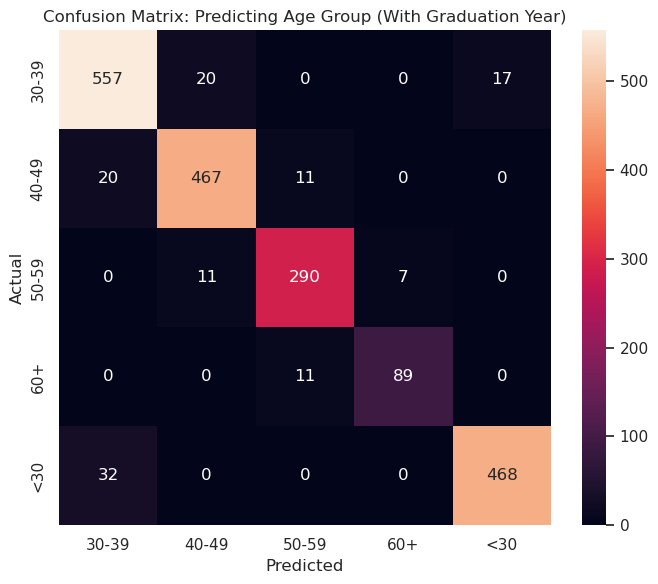

In [20]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm_with, annot=True, fmt="d", xticklabels=age_labels, yticklabels=age_labels)
plt.title("Confusion Matrix: Predicting Age Group (With Graduation Year)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

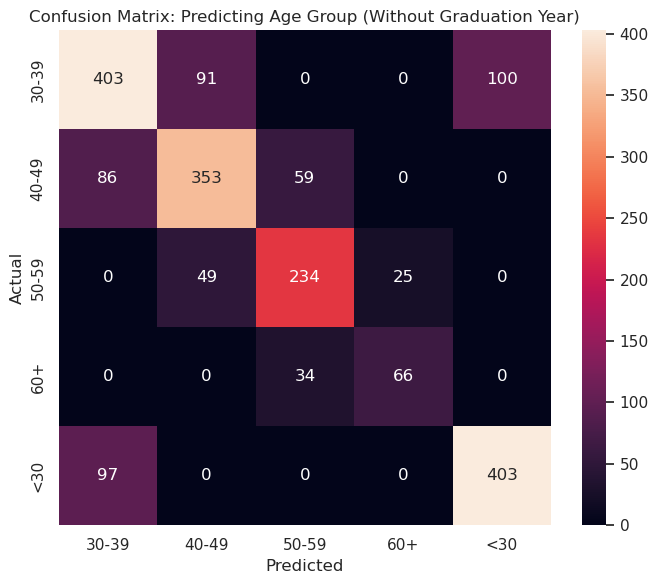

In [21]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm_without, annot=True, fmt="d", xticklabels=age_labels, yticklabels=age_labels)
plt.title("Confusion Matrix: Predicting Age Group (Without Graduation Year)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Feature Importance / Coefficient Inspection

To better understand how age-related information is encoded in the feature space, we inspect the learned coefficients of the logistic regression model.

Because the model uses a one-hot encoded and scaled feature representation, coefficients indicate the relative contribution of each transformed feature to predicting age group.

We focus on the features with the largest magnitude coefficients, which represent the strongest signals used by the model.

In [25]:
def get_feature_names_from_pipeline(pipeline, X):
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "num":
            feature_names.extend(columns)

        elif name == "cat":
            ohe = transformer.named_steps["onehot"]
            ohe_features = ohe.get_feature_names_out(columns)
            feature_names.extend(ohe_features)

        elif name == "bool":
            feature_names.extend(columns)

    return feature_names

In [27]:
feature_names_with = get_feature_names_from_pipeline(model_with, X_with_train)

coefs_with = model_with.named_steps["classifier"].coef_
classes = model_with.named_steps["classifier"].classes_

In [28]:
coef_df = pd.DataFrame(
    coefs_with,
    columns=feature_names_with,
    index=classes
)

coef_df.head()

,application_year,graduation_year,school_tier,years_experience_total,years_experience_relevant,num_employers,avg_tenure_years,months_since_last_role,num_gaps_over_6mo,management_years,...,skill_spark,skill_terraform,skill_linux,skill_ml,has_top_cloud_cert,github_url_present,portfolio_url_present,open_source_mentions,willing_to_relocate,remote_only
30-39,0.0,8.104472,0.031310,-1.305658,-0.338927,-0.019167,0.022098,0.111254,-0.035788,-0.037488,...,-0.164157,0.111638,-0.208096,-0.046921,0.038285,0.064888,-0.044531,0.109938,0.066568,0.037116
40-49,0.0,-1.727199,-0.001445,-0.209415,0.184827,-0.120289,0.020777,0.017153,-0.037727,0.087167,...,-0.071425,0.032748,-0.101100,-0.015484,0.057678,0.069072,-0.123628,0.033290,0.047629,0.070843
50-59,0.0,-9.880773,-0.042335,1.033174,0.486170,0.132407,0.052110,-0.051490,0.033497,0.037639,...,0.104810,-0.167397,0.002109,0.186213,0.064222,0.019675,0.066970,-0.008555,-0.054623,0.171307
60+,0.0,-17.058424,-0.062807,1.847693,1.028074,0.276328,0.058517,-0.162221,0.050126,0.033968,...,0.455615,-0.296984,0.262189,-0.033223,-0.465967,-0.251915,0.137141,-0.127271,-0.054881,-0.181927
<30,0.0,20.561924,0.075278,-1.365793,-1.360143,-0.269279,-0.153502,0.085304,-0.010109,-0.121286,...,-0.324843,0.319995,0.044898,-0.090585,0.305781,0.098279,-0.035953,-0.007402,-0.004693,-0.097339


In [29]:
def top_features_per_class(coef_df, top_n=10):
    results = {}

    for cls in coef_df.index:
        coefs = coef_df.loc[cls]

        top_positive = coefs.sort_values(ascending=False).head(top_n)
        top_negative = coefs.sort_values(ascending=True).head(top_n)

        results[cls] = {
            "top_positive": top_positive,
            "top_negative": top_negative,
        }

    return results

In [30]:
top_features = top_features_per_class(coef_df, top_n=10)

In [31]:
for cls, vals in top_features.items():
    print(f"\n===== Age Group: {cls} =====")

    print("\nTop Positive Features:")
    print(vals["top_positive"])

    print("\nTop Negative Features:")
    print(vals["top_negative"])


===== Age Group: 30-39 =====

Top Positive Features:
graduation_year                      8.104472
gpa_bucket_3.0-3.4                   0.322501
modern_tech_count                    0.180977
highest_degree_MS                    0.155379
target_role_family_SWE               0.154931
highest_degree_Bootcamp              0.152427
most_recent_title_Junior Engineer    0.134522
most_recent_company_size_51-200      0.133195
target_role_family_Sales             0.124417
most_recent_title_Intern             0.118692
Name: 30-39, dtype: float64

Top Negative Features:
years_experience_total      -1.305658
years_experience_relevant   -0.338927
salary_expectation_usd      -0.241926
highest_degree_PhD          -0.227747
skill_linux                 -0.208096
legacy_tech_count           -0.183269
gpa_bucket_3.8+             -0.182199
skill_spark                 -0.164157
region_EU                   -0.149991
target_role_family_Data     -0.142232
Name: 30-39, dtype: float64

===== Age Group: 40-49 ==

## Interpretation

The coefficient analysis reveals that age-related information is not encoded in a single feature, but rather distributed across multiple correlated variables.

As expected, `graduation_year` is a strong direct proxy for age, with large positive coefficients for younger groups and large negative coefficients for older groups. However, even beyond this feature, the model relies heavily on other signals.

For older age groups, the strongest positive predictors include years of experience, management history, legacy technology exposure, salary expectations, and number of prior employers. For younger groups, the model relies on lower experience levels, modern technology signals, and early-career job titles.

This pattern indicates that age is redundantly encoded across the feature space. Rather than depending on a single variable, the model reconstructs age using a combination of experience, titles, compensation, and technical profile.

These findings explain the results of the ablation study. Even after removing `graduation_year`, the model continues to exhibit age-related disparities because the remaining features still contain sufficient information to infer age.

This demonstrates that proxy bias in resume screening systems is a structural property of the feature space, not the result of any single attribute.

Notably, the model does not require perfect reconstruction of age to reproduce disparities. Even partial recoverability of age-related information is sufficient to generate unequal outcomes across groups. This suggests that fairness interventions based solely on feature removal may be insufficient in high-dimensional, correlated feature spaces.

## Save Outputs

In [32]:
reports_tables_dir = PROJECT_ROOT / "reports" / "tables"
reports_figures_dir = PROJECT_ROOT / "reports" / "figures"
models_dir = PROJECT_ROOT / "models"

reports_tables_dir.mkdir(parents=True, exist_ok=True)
reports_figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

In [33]:
age_predictability_results.to_csv(
    reports_tables_dir / "age_group_predictability_results.csv",
    index=False
)

joblib.dump(model_with, models_dir / "age_group_predictor_with_grad_year.joblib")
joblib.dump(model_without, models_dir / "age_group_predictor_without_grad_year.joblib")

['/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/models/age_group_predictor_without_grad_year.joblib']